In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


In [3]:
df = pd.read_csv("../data/processed/merged_clean.csv", parse_dates=["datetime"])

In [4]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.weekday
df["is_weekend"] = df["weekday"] >= 5

df.head()


,client_id,value,datetime,hour,day,month,weekday,is_weekend
0,MAC000002,0.263,2012-10-13 00:00:00,0,13,10,5,True
1,MAC000002,0.269,2012-10-13 00:30:00,0,13,10,5,True
2,MAC000002,0.275,2012-10-13 01:00:00,1,13,10,5,True
3,MAC000002,0.256,2012-10-13 01:30:00,1,13,10,5,True
4,MAC000002,0.211,2012-10-13 02:00:00,2,13,10,5,True


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

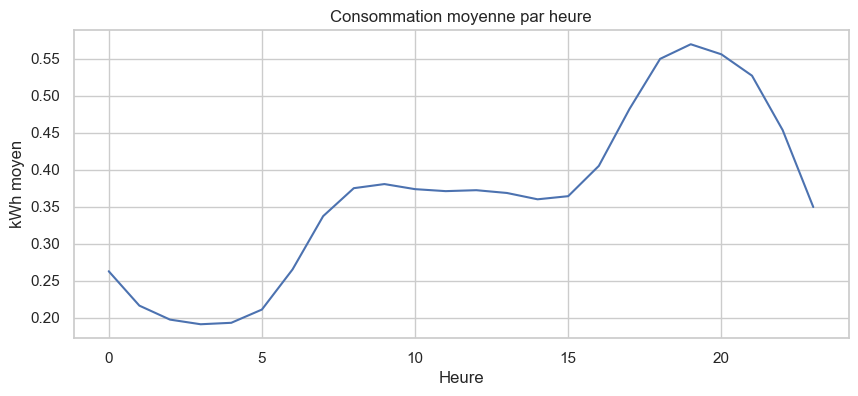

In [5]:
df_hourly = df.groupby("hour")["value"].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(x=df_hourly.index, y=df_hourly.values)
plt.title("Consommation moyenne par heure")
plt.xlabel("Heure")
plt.ylabel("kWh moyen")
plt.grid(True)
plt.show()


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.ap

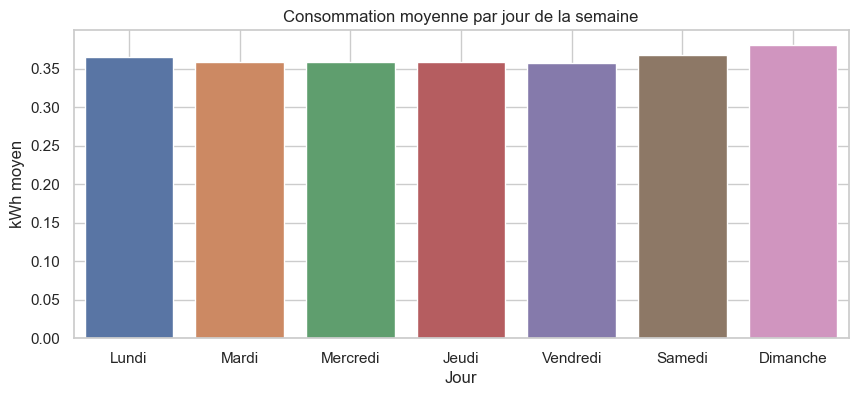

In [6]:
df_weekday = df.groupby("weekday")["value"].mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"],
            y=df_weekday.values)
plt.title("Consommation moyenne par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("kWh moyen")
plt.grid(True)
plt.show()


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

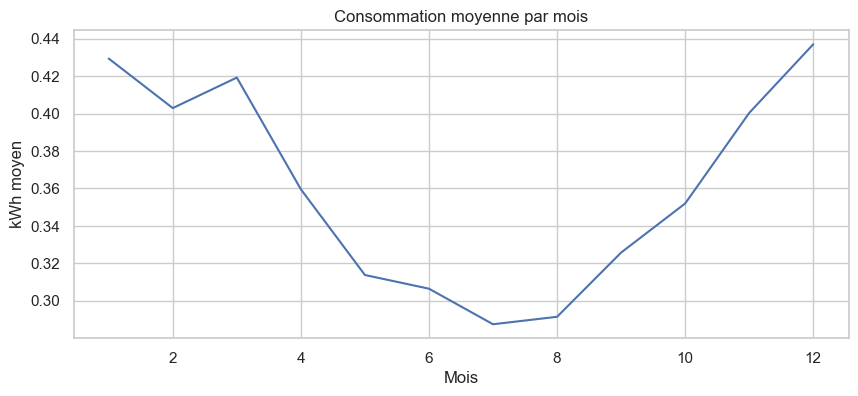

In [7]:
df_monthly = df.groupby("month")["value"].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(x=df_monthly.index, y=df_monthly.values)
plt.title("Consommation moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("kWh moyen")
plt.grid(True)
plt.show()


In [8]:
df.to_csv("../data/processed/merged_enriched.csv", index=False)

